In [1]:
from sklearn.cluster import KMeans
import numpy as np
X = np.array([[1, 2], [2, 4], [1, 0],
              [5, 2], [10, 4], [8, 0]])
print(X)
kmeans = KMeans(n_clusters=2, random_state=0, n_init="auto").fit(X)
print(kmeans.cluster_centers_)
print(kmeans.labels_)
print(kmeans.predict([[21, 0], [12, 3], [6, 3]]))
print(kmeans.transform([[21, 0], [12, 3], [6, 3]]))
print(kmeans.inertia_)
print(X)

[[ 1  2]
 [ 2  4]
 [ 1  0]
 [ 5  2]
 [10  4]
 [ 8  0]]
[[2.25 2.  ]
 [9.   2.  ]]
[0 0 0 0 1 1]
[1 1 1]
[[18.85636497 12.16552506]
 [ 9.80114789  3.16227766]
 [ 3.88104367  3.16227766]]
28.75
[[ 1  2]
 [ 2  4]
 [ 1  0]
 [ 5  2]
 [10  4]
 [ 8  0]]


## Real-world example: clustering Iris flowers
We cluster the Iris dataset using K-Means, then visualize clusters with PCA.


[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 0 0 0 2 0 0 0 0 0 0 0 0 2 0 0 0 0 2 0 0 0
 0 2 2 2 0 0 0 0 0 0 0 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 2 2 2 2 2 2 0 0 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]


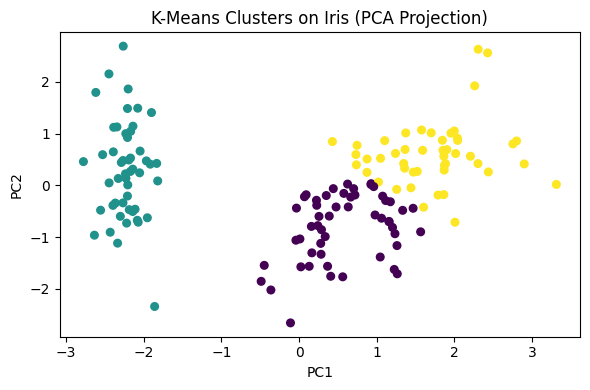

Cluster centers (approx. original units):
[[5.8  2.67 4.37 1.41]
 [5.01 3.43 1.46 0.25]
 [6.78 3.1  5.51 1.97]]


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Load data
iris = load_iris()
X = iris.data

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# print(X_scaled)

# Fit K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)
print(labels)

# Reduce to 2D for visualization
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

# Plot clusters
plt.figure(figsize=(6, 4))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='viridis', s=30)
plt.title('K-Means Clusters on Iris (PCA Projection)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()

# Optional: inspect cluster centers in original feature space
centers = scaler.inverse_transform(kmeans.cluster_centers_)
print('Cluster centers (approx. original units):')
print(np.round(centers, 2))


## Real use case: retail store customer segmentation (step by step)
We segment customers using simple retail behaviors: recency, frequency, and monetary value.

**Steps**
1. Build a customer feature table (recency, purchase frequency, average basket size).
2. Scale features so one metric does not dominate the others.
3. Run K-Means to form segments.
4. Visualize segments and summarize each group.


    recency_days  frequency_6mo  avg_basket_usd
0      31.377259              4       60.225554
1      42.530184              7       58.038529
2      27.558234              9       47.014742
3      24.676056              6       30.288760
4      46.188830              7       61.853589
5      26.300603              7       44.632887
6      35.190076              6       61.719870
7      32.842291              8       44.119129
8      46.161204             12       38.006833
9      21.588308              6       64.685967
10     56.933758              3       63.018431
11     17.588974              5       71.585639
12     36.789796             13      103.717275
13     33.874530             11       65.545791
14     16.334585              8       69.701635
15     38.926121              6       38.448773
16     22.857700              3       34.261851
17     12.191654              8       91.656589
18     42.331880              3       41.530404
19      8.487055              7       39

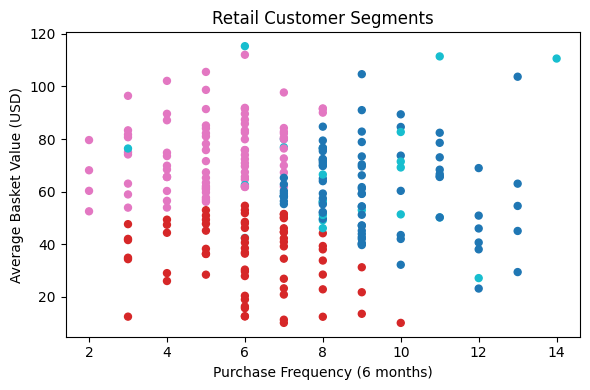

         recency_days  frequency_6mo  avg_basket_usd  customers
segment                                                        
0               23.32           9.26           61.08         80
1               27.35           6.09           35.15         67
2               27.34           5.11           75.04         81
3               78.77           8.55           67.36         22


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1) Create a simple retail-style dataset (synthetic for demo)
rng = np.random.default_rng(42)
# print(rng)
n_customers = 250

# Recency: days since last purchase (lower is better)
recency = rng.gamma(shape=2.0, scale=15.0, size=n_customers)

# Frequency: number of purchases in last 6 months
frequency = rng.poisson(lam=6.0, size=n_customers) + 1

# Monetary: average basket value in USD
monetary = rng.normal(loc=60.0, scale=20.0, size=n_customers)
monetary = np.clip(monetary, 10, None)

retail = pd.DataFrame({
    'recency_days': recency,
    'frequency_6mo': frequency,
    'avg_basket_usd': monetary,
})
print(retail.head(20))

# 2) Scale features
scaler = StandardScaler()
X = scaler.fit_transform(retail)

# 3) Fit K-Means
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)
retail['segment'] = labels

# 4) Visualize segments (frequency vs. monetary)
plt.figure(figsize=(6, 4))
plt.scatter(retail['frequency_6mo'], retail['avg_basket_usd'], c=labels, cmap='tab10', s=25)
plt.title('Retail Customer Segments')
plt.xlabel('Purchase Frequency (6 months)')
plt.ylabel('Average Basket Value (USD)')
plt.tight_layout()
plt.show()

# Segment summary for business interpretation
summary = retail.groupby('segment').agg({
    'recency_days': 'mean',
    'frequency_6mo': 'mean',
    'avg_basket_usd': 'mean',
    'segment': 'count'
}).rename(columns={'segment': 'customers'})

print(summary.round(2))


In [4]:
# https://www.kaggle.com/code/abdallah3gag/customer-segmentation-clustering ( optional )
#http://www.saedsayad.com/clustering_kmeans.htm ( please refer this one )
# https://web.iitd.ac.in/~bspanda/clustering.pdf
# https://www.cse.iitm.ac.in/~vplab/courses/SLT/PDF/CSLT-CLUSTERING_Apr-23.pdf


In [5]:
#Assignment:
# 1. Explore DBSCAN and Hierarchical Clustering algorithms 
# on the same datasets used above.

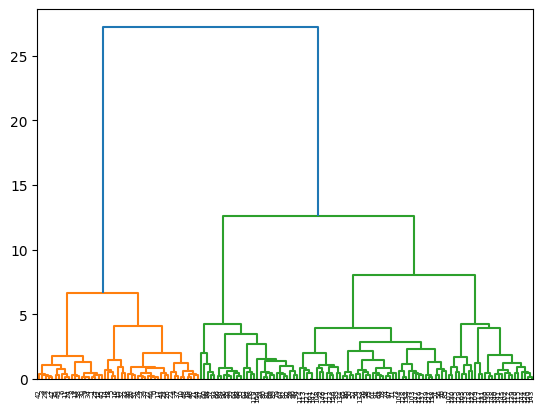

In [6]:
# Hierarchical Clustering algorithms

import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

# NOTE Hierarchical clustering 

# builds a tree-like structure (dendrogram) that shows how data points are grouped step by step.
# Unlike K-Means, you don’t need to pre-define K.

# Types of Hierarchical Clustering
# 1️⃣ Agglomerative (Bottom-Up) — Most Common

# Start with each data point as its own cluster

# Repeatedly merge the closest clusters

# Stop when desired number of clusters is reached

iris = load_iris()
X = iris.data
X_scaled = StandardScaler().fit_transform(X)

model = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward'
)

labels = model.fit_predict(X_scaled)
labels

from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

Z = linkage(X_scaled, method='ward')
dendrogram(Z)
plt.show()

[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1 -1  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0 -1 -1  0  0  0  0  0  0  0 -1  0  0  0  0  0  0
  0  0  1  1  1  1  1  1 -1 -1  1 -1 -1  1 -1  1  1  1  1  1 -1  1  1  1
 -1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1 -1  1  1  1  1  1 -1  1  1
  1  1 -1  1 -1  1  1  1  1 -1 -1 -1 -1 -1  1  1  1  1 -1  1  1 -1 -1 -1
  1  1 -1  1  1 -1  1  1  1 -1 -1 -1  1  1  1 -1 -1  1  1  1  1  1  1  1
  1  1  1  1 -1  1]


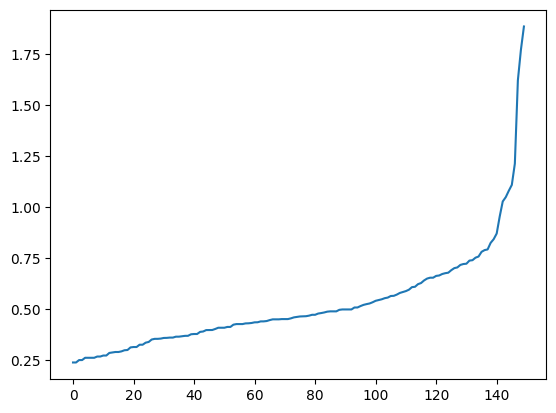

In [7]:
# DB Scan clustering algorithm

# DBSCAN Algorithm (Density-Based Spatial Clustering of Applications with Noise)
# DBSCAN is a density-based clustering algorithm that groups points which are closely packed together and labels isolated points as noise (outliers).

# Key Idea (Intuition)
# “Clusters are regions of high density, separated by regions of low density.”

# Unlike K-Means:
# ❌ No need to specify number of clusters
# ✅ Can find arbitrary-shaped clusters
# ✅ Automatically detects outliers

# Important Parameters
# 1️⃣ eps (ε) – Radius
# Maximum distance to consider points as neighbors
# 2️⃣ min_samples – Minimum Points
# Minimum number of points required to form a dense region

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

iris = load_iris()
X = iris.data
X_scaled = StandardScaler().fit_transform(X)

dbscan = DBSCAN(eps=0.5, min_samples=5)
labels = dbscan.fit_predict(X_scaled)
print(labels)

from sklearn.neighbors import NearestNeighbors
import numpy as np

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:,4])
plt.plot(distances)